In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harshskartik/churn-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'churn-dataset' dataset.
Path to dataset files: /kaggle/input/churn-dataset


In [ ]:
import os

source_path = '/root/.cache/kagglehub/datasets/harshskartik/churn-dataset/versions/1'
destination_path = '/content/churn-dataset'

# Create the destination directory if it doesn't exist
os.makedirs(destination_path, exist_ok=True)

# Move the contents of the source directory to the destination directory
!mv {source_path}/* {destination_path}/

print(f"Dataset moved from {source_path} to {destination_path}")
print(f"Contents of {destination_path}:")
!ls {destination_path}

mv: cannot stat '/root/.cache/kagglehub/datasets/harshskartik/churn-dataset/versions/1/*': No such file or directory
Dataset moved from /root/.cache/kagglehub/datasets/harshskartik/churn-dataset/versions/1 to /content/churn-dataset
Contents of /content/churn-dataset:
Churn.csv  quiz.ipynb


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/churn-dataset/Churn.csv')

In [ ]:
df.shape

(7044, 21)

In [ ]:
df.head()

,Customer ID,Gender,Senior Citizen,Partner,Dependents,tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,7590-VHVEA,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7044 entries, 0 to 7043
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        7044 non-null   object 
 1   Gender             7044 non-null   object 
 2   Senior Citizen     7044 non-null   int64  
 3   Partner            7044 non-null   object 
 4   Dependents         7044 non-null   object 
 5   tenure             7044 non-null   int64  
 6   Phone Service      7044 non-null   object 
 7   Multiple Lines     7044 non-null   object 
 8   Internet Service   7044 non-null   object 
 9   Online Security    7044 non-null   object 
 10  Online Backup      7044 non-null   object 
 11  Device Protection  7044 non-null   object 
 12  Tech Support       7044 non-null   object 
 13  Streaming TV       7044 non-null   object 
 14  Streaming Movies   7044 non-null   object 
 15  Contract           7044 non-null   object 
 16  Paperless Billing  7044 

We can see that there are many columns with the wrong data type(For eg Total Charges as Object).
We need to convert these columns to the correct data type before proceding to the modelling stage.

In [ ]:
df.describe()

,Senior Citizen,tenure,Monthly Charges
count,7044.000000,7044.000000,7044.000000
mean,0.162124,32.366695,64.756736
std,0.368590,24.560582,30.090786
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Objectives
1. Convert to correct data type.
2. Drop/Fill missing values if any
3. Exploratory Data Analysis.

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Senior Citizen'] = df['Senior Citizen'].astype('category')


In [ ]:
df['Senior Citizen'] = df['Senior Citizen'].cat.rename_categories({0: 'No', 1: 'Yes'})
print("Value counts for 'Senior Citizen' after mapping:")
print(df['Senior Citizen'].value_counts())

Value counts for 'Senior Citizen' after mapping:
Senior Citizen
No     5902
Yes    1142
Name: count, dtype: int64


In [ ]:
df.head()

,Customer ID,Gender,Senior Citizen,Partner,Dependents,tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,7590-VHVEA,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].astype('category')

In [ ]:
bins = [0, 12, 24, 36, 48, 60, np.inf]
labels = ['1 year', '2 years', '3 years', '4 years', '5 years', '5+ years']

df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

print("Value counts for 'tenure_group':")
print(df['tenure_group'].value_counts().sort_index())
print("\nFirst 5 rows with 'tenure_group':")
print(df[['tenure', 'tenure_group']].head())

Value counts for 'tenure_group':
tenure_group
1 year      2176
2 years     1024
3 years      832
4 years      762
5 years      832
5+ years    1407
Name: count, dtype: int64

First 5 rows with 'tenure_group':
   tenure tenure_group
0       1       1 year
1       1       1 year
2      34      3 years
3       2       1 year
4      45      4 years


Since we had only 11 missing values, I decided to drop them.

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,tenure_group
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 year
1,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 year
2,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,3 years
3,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 year
4,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4 years


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7033 entries, 0 to 7043
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Gender             7033 non-null   category
 1   Senior Citizen     7033 non-null   category
 2   Partner            7033 non-null   category
 3   Dependents         7033 non-null   category
 4   Phone Service      7033 non-null   category
 5   Multiple Lines     7033 non-null   category
 6   Internet Service   7033 non-null   category
 7   Online Security    7033 non-null   category
 8   Online Backup      7033 non-null   category
 9   Device Protection  7033 non-null   category
 10  Tech Support       7033 non-null   category
 11  Streaming TV       7033 non-null   category
 12  Streaming Movies   7033 non-null   category
 13  Contract           7033 non-null   category
 14  Paperless Billing  7033 non-null   category
 15  Payment Method     7033 non-null   category
 16  Monthly Cha

Our dataset is ready for EDA.

# EDA

Churn distribution:
Churn
No     5164
Yes    1869
Name: count, dtype: int64

Churn distribution (%):
Churn
No     73.425281
Yes    26.574719
Name: proportion, dtype: float64


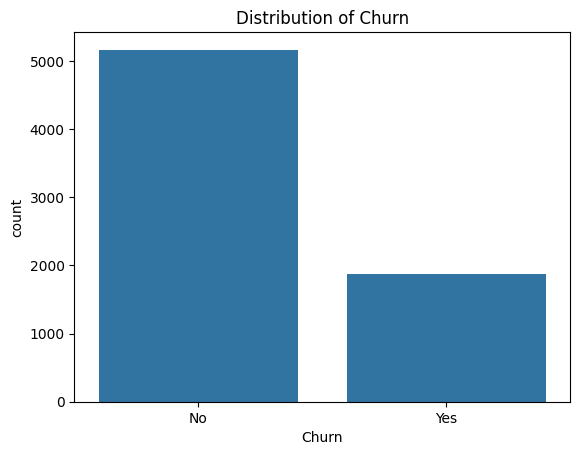

In [ ]:
print('Churn distribution:')
print(df['Churn'].value_counts())
print('\nChurn distribution (%):')
print(df['Churn'].value_counts(normalize=True) * 100)

sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

This plot shows us that the dataset is slightly imbalanced.
We will have to correct this during the modelling stage.

Churn counts by Gender:
Churn     No  Yes
Gender           
Female  2545  939
Male    2619  930

Churn percentage by Gender:
Churn          No        Yes
Gender                      
Female  73.048220  26.951780
Male    73.795435  26.204565


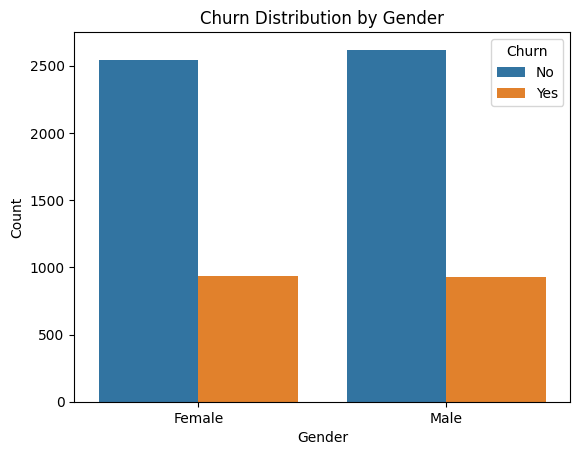

In [ ]:
gender_churn_counts = pd.crosstab(df['Gender'], df['Churn'])
print("Churn counts by Gender:")
print(gender_churn_counts)

gender_churn_percentage = pd.crosstab(df['Gender'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Gender:")
print(gender_churn_percentage)

sns.countplot(data=df, x='Gender', hue='Churn')
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Gender Has Little to No Impact on Churn

Churn counts by Senior Citizen:
Churn             No   Yes
Senior Citizen            
No              4498  1393
Yes              666   476

Churn percentage by Senior Citizen:
Churn                  No        Yes
Senior Citizen                      
No              76.353760  23.646240
Yes             58.318739  41.681261


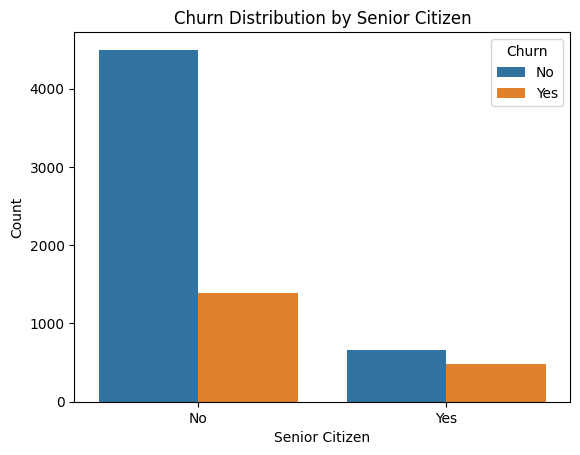

In [ ]:
senior_citizen_churn_counts = pd.crosstab(df['Senior Citizen'], df['Churn'])
print("Churn counts by Senior Citizen:")
print(senior_citizen_churn_counts)

senior_citizen_churn_percentage = pd.crosstab(df['Senior Citizen'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Senior Citizen:")
print(senior_citizen_churn_percentage)

sns.countplot(data=df, x='Senior Citizen', hue='Churn')
plt.title('Churn Distribution by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')
plt.show()

Senior Citizens Churn significantly more.

Possible Reasons:
1. Poor tech support
2. Poor cellular service when move to different city to live with kids.
eg -BSNL in cities vs Villages.

Churn counts by Internet Service:
Churn               No   Yes
Internet Service            
DSL               1958   459
Fiber optic       1799  1297
No                1407   113

Churn percentage by Internet Service:
Churn                    No        Yes
Internet Service                      
DSL               81.009516  18.990484
Fiber optic       58.107235  41.892765
No                92.565789   7.434211


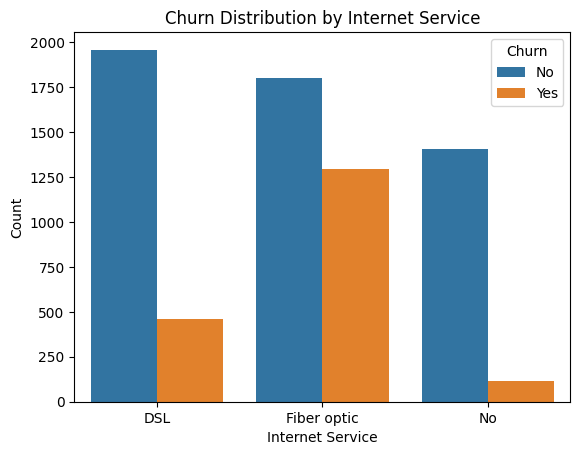

In [ ]:
internet_service_churn_counts = pd.crosstab(df['Internet Service'], df['Churn'])
print("Churn counts by Internet Service:")
print(internet_service_churn_counts)

internet_service_churn_percentage = pd.crosstab(df['Internet Service'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Internet Service:")
print(internet_service_churn_percentage)

sns.countplot(data=df, x='Internet Service', hue='Churn')
plt.title('Churn Distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

Internet Service type is a strong predictor of churn, with Fiber optic customers showing significantly higher churn rates.

Possible Reasons for churning:
1. Fiber optic services are often costly.
2. Not getting the expected speed even after using Fibre optic cables.

Churn counts by Online Security:
Churn                  No   Yes
Online Security                
No                   2037  1461
No internet service  1407   113
Yes                  1720   295

Churn percentage by Online Security:
Churn                       No        Yes
Online Security                          
No                   58.233276  41.766724
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199


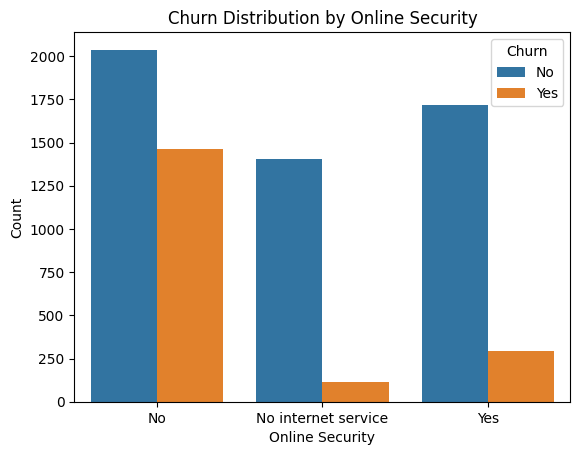

In [ ]:
online_security_churn_counts = pd.crosstab(df['Online Security'], df['Churn'])
print("Churn counts by Online Security:")
print(online_security_churn_counts)

online_security_churn_percentage = pd.crosstab(df['Online Security'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Online Security:")
print(online_security_churn_percentage)

sns.countplot(data=df, x='Online Security', hue='Churn')
plt.title('Churn Distribution by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Count')
plt.show()

Similar to Internet Service, Online Security is also a important feature for retaining customers.

Possible Reasons for churning:
1. Privacy concerns

Churn counts by Tech Support:
Churn                  No   Yes
Tech Support                   
No                   2027  1446
No internet service  1407   113
Yes                  1730   310

Churn percentage by Tech Support:
Churn                       No        Yes
Tech Support                             
No                   58.364526  41.635474
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


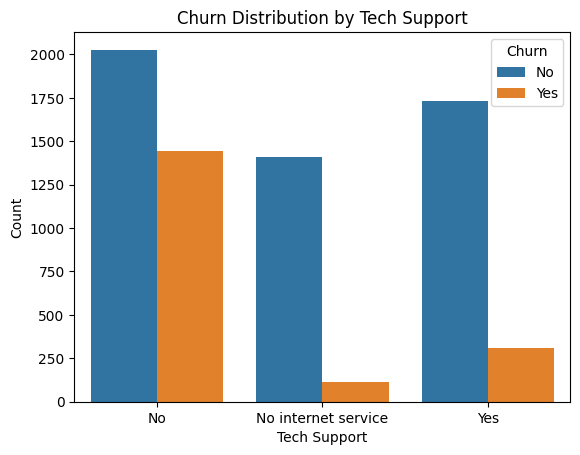

In [ ]:
tech_support_churn_counts = pd.crosstab(df['Tech Support'], df['Churn'])
print("Churn counts by Tech Support:")
print(tech_support_churn_counts)

tech_support_churn_percentage = pd.crosstab(df['Tech Support'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Tech Support:")
print(tech_support_churn_percentage)

sns.countplot(data=df, x='Tech Support', hue='Churn')
plt.title('Churn Distribution by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.show()

Tech support is also a good Indicator of churning customers.

Possible Reasons for churning:
1. No immediate resolution of problems.

Churn counts by Streaming TV:
Churn                  No  Yes
Streaming TV                  
No                   1868  942
No internet service  1407  113
Yes                  1889  814

Churn percentage by Streaming TV:
Churn                       No        Yes
Streaming TV                             
No                   66.476868  33.523132
No internet service  92.565789   7.434211
Yes                  69.885313  30.114687


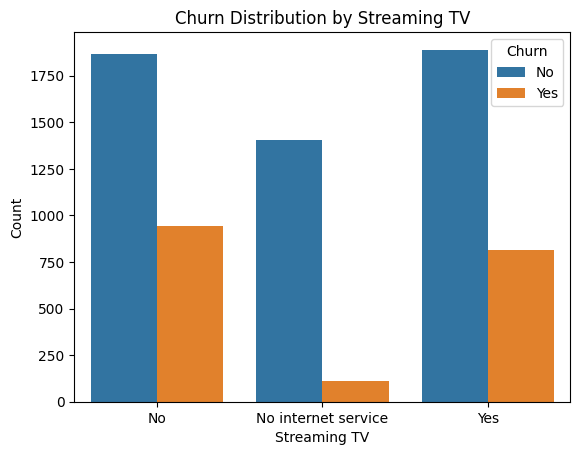

In [ ]:
streaming_tv_churn_counts = pd.crosstab(df['Streaming TV'], df['Churn'])
print("Churn counts by Streaming TV:")
print(streaming_tv_churn_counts)

streaming_tv_churn_percentage = pd.crosstab(df['Streaming TV'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Streaming TV:")
print(streaming_tv_churn_percentage)

sns.countplot(data=df, x='Streaming TV', hue='Churn')
plt.title('Churn Distribution by Streaming TV')
plt.xlabel('Streaming TV')
plt.ylabel('Count')
plt.show()

Customers with Streaming TV churn slightly less.

Churn counts by Streaming Movies:
Churn                  No  Yes
Streaming Movies              
No                   1844  938
No internet service  1407  113
Yes                  1913  818

Churn percentage by Streaming Movies:
Churn                       No        Yes
Streaming Movies                         
No                   66.283249  33.716751
No internet service  92.565789   7.434211
Yes                  70.047602  29.952398


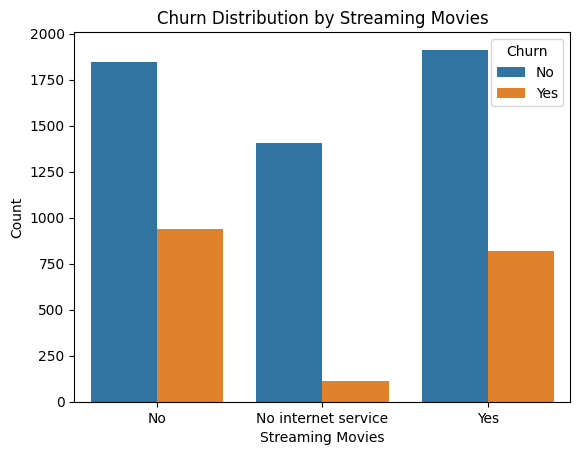

In [ ]:
streaming_movies_churn_counts = pd.crosstab(df['Streaming Movies'], df['Churn'])
print("Churn counts by Streaming Movies:")
print(streaming_movies_churn_counts)

streaming_movies_churn_percentage = pd.crosstab(df['Streaming Movies'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Streaming Movies:")
print(streaming_movies_churn_percentage)

sns.countplot(data=df, x='Streaming Movies', hue='Churn')
plt.title('Churn Distribution by Streaming Movies')
plt.xlabel('Streaming Movies')
plt.ylabel('Count')
plt.show()

Similar to Streaming TV, people who get access to movies are slightly less likely to churn.

Churn counts by Contract:
Churn             No   Yes
Contract                  
Month-to-month  2221  1655
One year        1306   166
Two year        1637    48

Churn percentage by Contract:
Churn                  No        Yes
Contract                            
Month-to-month  57.301342  42.698658
One year        88.722826  11.277174
Two year        97.151335   2.848665


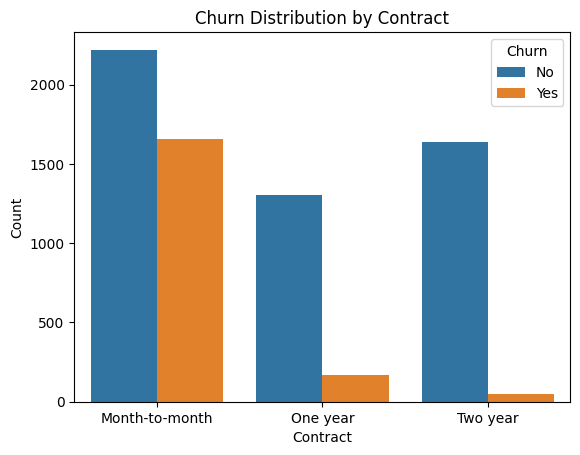

In [ ]:
contract_churn_counts = pd.crosstab(df['Contract'], df['Churn'])
print("Churn counts by Contract:")
print(contract_churn_counts)

contract_churn_percentage = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Contract:")
print(contract_churn_percentage)

sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Distribution by Contract')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.show()

contract length is the strongest determinant of churn yet.

Possible Reasons:
1. Long contracts are harder to leave.
2. Incentives for longer contracts are very lucrative.


Churn counts by Tenure Group:
Churn           No   Yes
tenure_group            
1 year        1139  1037
2 years        730   294
3 years        652   180
4 years        617   145
5 years        712   120
5+ years      1314    93

Churn percentage by Tenure Group:
Churn                No        Yes
tenure_group                      
1 year        52.343750  47.656250
2 years       71.289062  28.710938
3 years       78.365385  21.634615
4 years       80.971129  19.028871
5 years       85.576923  14.423077
5+ years      93.390192   6.609808


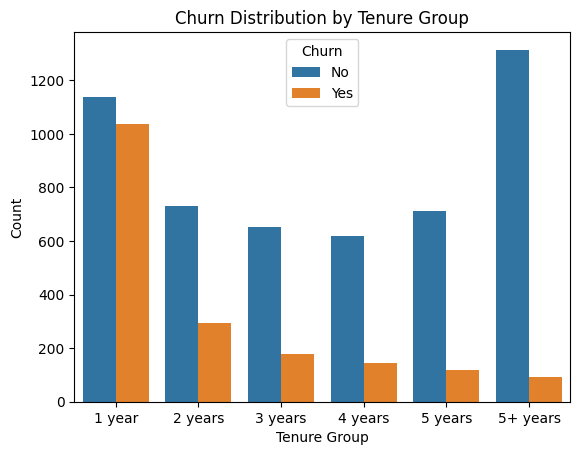

In [ ]:
tenure_group_churn_counts = pd.crosstab(df['tenure_group'], df['Churn'])
print("Churn counts by Tenure Group:")
print(tenure_group_churn_counts)

tenure_group_churn_percentage = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Tenure Group:")
print(tenure_group_churn_percentage)

sns.countplot(data=df, x='tenure_group', hue='Churn', order=df['tenure_group'].cat.categories)
plt.title('Churn Distribution by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Count')
plt.show()

Customer churn is heavily concentrated in early tenure, and retention improves significantly over time.


Churn counts by Payment Method:
Churn                        No   Yes
Payment Method                       
Bank transfer (automatic)  1284   258
Credit card (automatic)    1289   232
Electronic check           1295  1071
Mailed check               1296   308

Churn percentage by Payment Method:
Churn                             No        Yes
Payment Method                                 
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.733728  45.266272
Mailed check               80.798005  19.201995


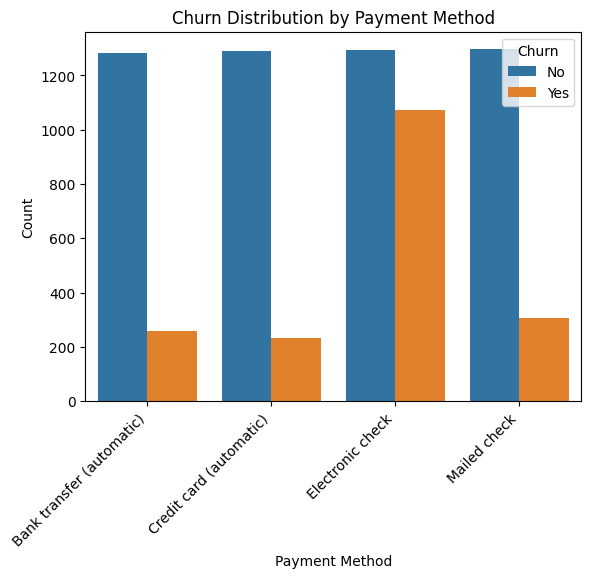

In [ ]:
payment_method_churn_counts = pd.crosstab(df['Payment Method'], df['Churn'])
print("Churn counts by Payment Method:")
print(payment_method_churn_counts)

payment_method_churn_percentage = pd.crosstab(df['Payment Method'], df['Churn'], normalize='index') * 100
print("\nChurn percentage by Payment Method:")
print(payment_method_churn_percentage)

sns.countplot(data=df, x='Payment Method', hue='Churn')
plt.title('Churn Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

Electronic Check Users Have Extremely High Churn rate.


--- Analysis for Phone Service ---
Churn counts by Phone Service:
Churn            No   Yes
Phone Service            
No              511   170
Yes            4653  1699

Churn percentage by Phone Service:
Churn                 No        Yes
Phone Service                      
No             75.036711  24.963289
Yes            73.252519  26.747481


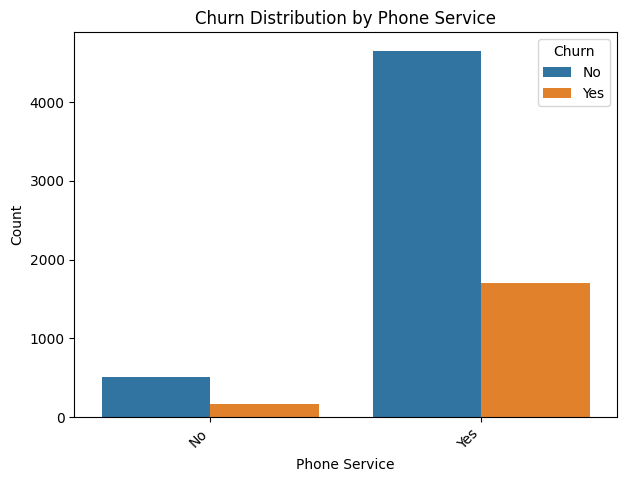


--- Analysis for Multiple Lines ---
Churn counts by Multiple Lines:
Churn               No  Yes
Multiple Lines             
No                2536  849
No phone service   511  170
Yes               2117  850

Churn percentage by Multiple Lines:
Churn                    No        Yes
Multiple Lines                        
No                74.918759  25.081241
No phone service  75.036711  24.963289
Yes               71.351534  28.648466


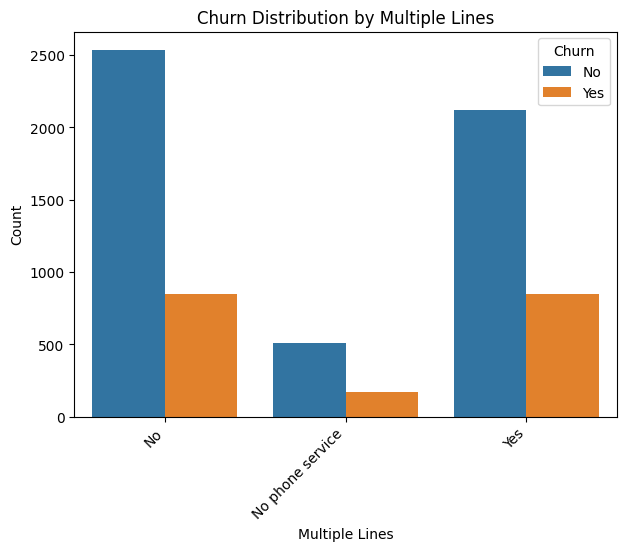


--- Analysis for Online Backup ---
Churn counts by Online Backup:
Churn                  No   Yes
Online Backup                  
No                   1854  1233
No internet service  1407   113
Yes                  1903   523

Churn percentage by Online Backup:
Churn                       No        Yes
Online Backup                            
No                   60.058309  39.941691
No internet service  92.565789   7.434211
Yes                  78.441880  21.558120


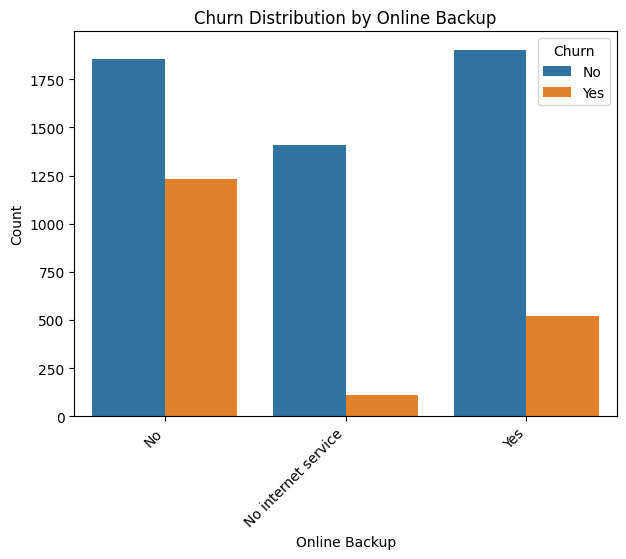


--- Analysis for Device Protection ---
Churn counts by Device Protection:
Churn                  No   Yes
Device Protection              
No                   1884  1211
No internet service  1407   113
Yes                  1873   545

Churn percentage by Device Protection:
Churn                       No        Yes
Device Protection                        
No                   60.872375  39.127625
No internet service  92.565789   7.434211
Yes                  77.460711  22.539289


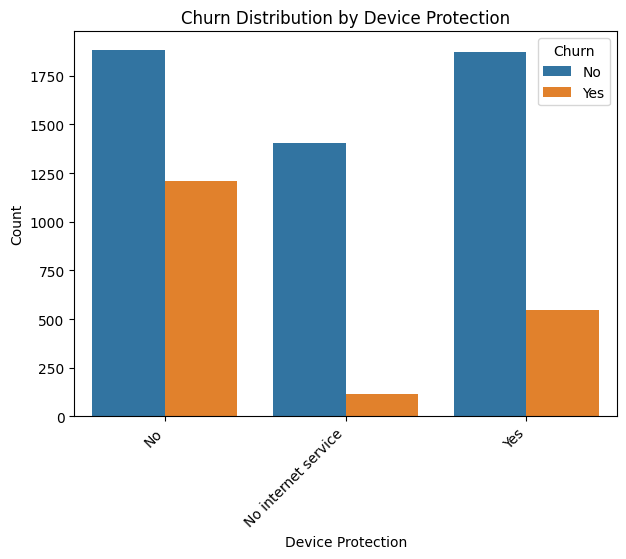


--- Analysis for Paperless Billing ---
Churn counts by Paperless Billing:
Churn                No   Yes
Paperless Billing            
No                 2395   469
Yes                2769  1400

Churn percentage by Paperless Billing:
Churn                     No        Yes
Paperless Billing                      
No                 83.624302  16.375698
Yes                66.418805  33.581195


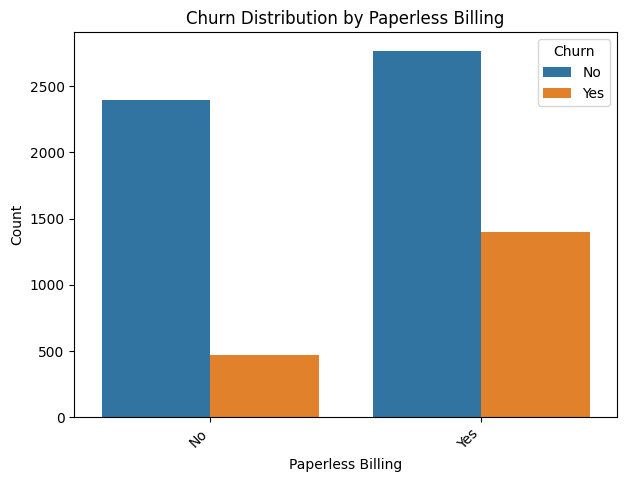

In [ ]:
features_to_analyze = ['Phone Service', 'Multiple Lines', 'Online Backup', 'Device Protection', 'Paperless Billing']

for feature in features_to_analyze:
    print(f"\n--- Analysis for {feature} ---")

    churn_counts = pd.crosstab(df[feature], df['Churn'])
    print(f"Churn counts by {feature}:")
    print(churn_counts)

    churn_percentage = pd.crosstab(df[feature], df['Churn'], normalize='index') * 100
    print(f"\nChurn percentage by {feature}:")
    print(churn_percentage)

    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, x=feature, hue='Churn')
    plt.title(f'Churn Distribution by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.show()

Online Backup & Device Protection have high churn signal.
Possible Reasons:
1. More Features less churn.

<Axes: xlabel='Churn', ylabel='Monthly Charges'>

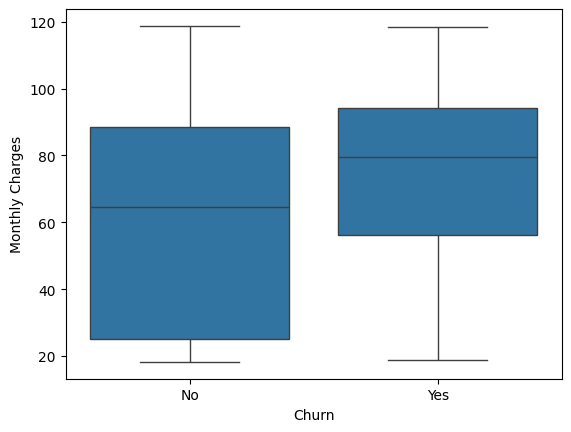

In [ ]:
sns.boxplot(x='Churn', y='Monthly Charges', data=df)

<Axes: xlabel='Churn', ylabel='Total Charges'>

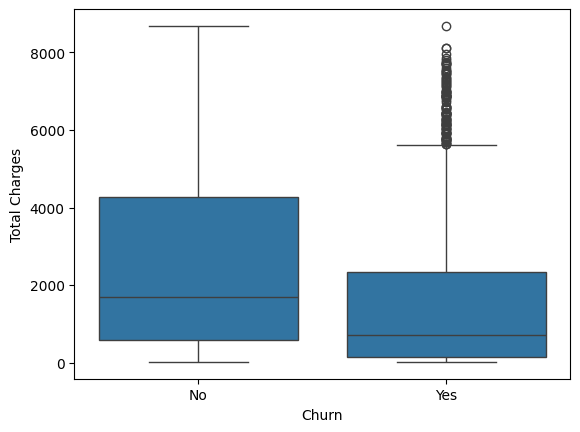

In [ ]:
sns.boxplot(x='Churn', y='Total Charges', data=df)

Do higher charges cause higher churn rate?


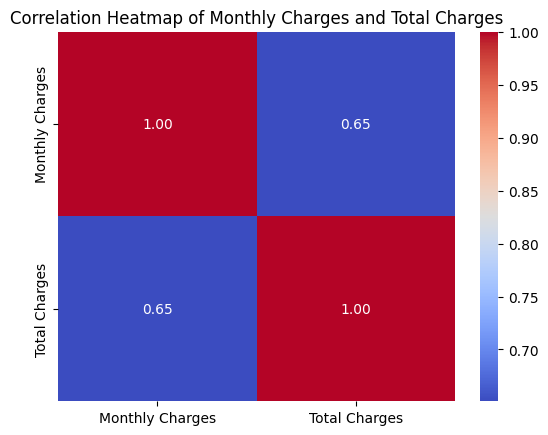

In [ ]:
correlation_matrix = df[['Monthly Charges', 'Total Charges']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Monthly Charges and Total Charges')
plt.show()

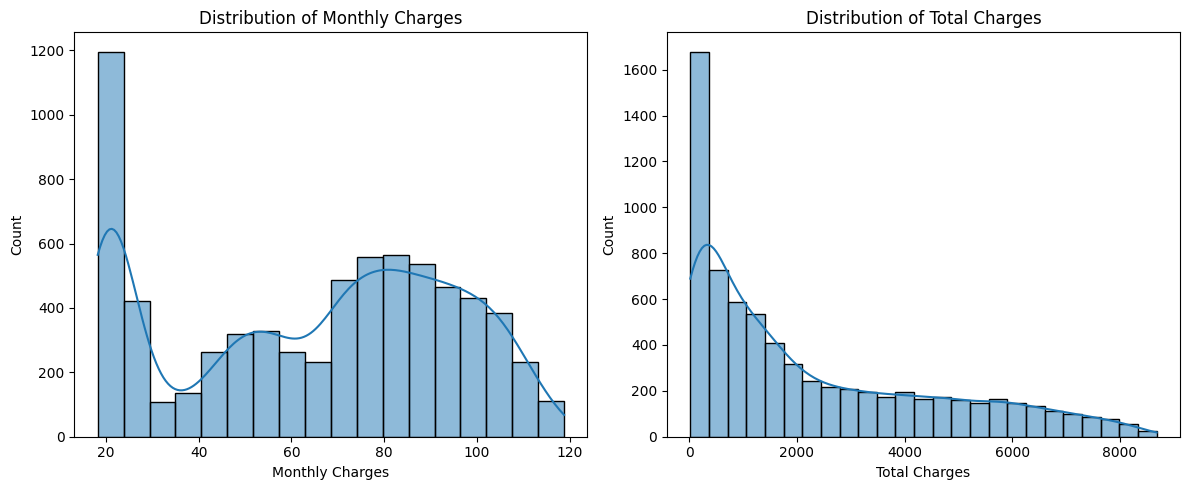

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Monthly Charges'], kde=True)
plt.title('Distribution of Monthly Charges')

plt.subplot(1, 2, 2)
sns.histplot(df['Total Charges'], kde=True)
plt.title('Distribution of Total Charges')

plt.tight_layout()
plt.show()

Multiple peaks in the monthly charges indicate multiple monthly plans for customers.

# Results

Based on our Exploratory Data Analysis, here are the top drivers for customer churn:

Contract Type: Customers on Month-to-month contracts have a significantly higher churn rate compared to those with One-year or Two-year contracts. This was identified as the strongest determinant.<br>
Tenure: Churn is heavily concentrated in the early tenure period. Customers who have been with the service for shorter durations are much more likely to churn, with retention improving significantly over time.<br>
Internet Service: Customers using Fiber optic internet service show a substantially higher churn rate compared to those with DSL or no internet service.<br>
Payment Method: Users who pay via Electronic check exhibit an extremely high churn rate.<br>
Senior Citizen Status: Senior citizens churn significantly more than non-senior citizens.<br>
Online Security & Tech Support: Customers without Online Security and Tech Support services have a higher likelihood of churning. This suggests these add-on services play a role in customer retention.<br>
Monthly Charges: While not explicitly stated as a 'top' driver like contract or tenure, the boxplot showed that customers who churn generally have higher Monthly Charges on average.<br>